In [ ]:
#importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

## Sobre a Base de Dados

### Superstore Sales Dataset

A base de dados utilizada neste projeto é o **Superstore Sales Dataset**, uma base pública disponível na plataforma Kaggle. Ela representa as operações comerciais de uma rede varejista americana e contém registros de pedidos realizados entre os anos de **2014 e 2017**.

A base é composta por **9.994 registros** e **21 variáveis**, cobrindo todo o ciclo de venda — do pedido ao envio, passando pelo perfil do cliente, localização geográfica, categoria do produto e resultado financeiro.

### Descrição das Colunas

| Coluna | Tipo | Descrição |
|---|---|---|
| Row ID | Numérica | Identificador único da linha |
| Order ID | Texto | Identificador único do pedido |
| Order Date | Data | Data em que o pedido foi realizado |
| Ship Date | Data | Data em que o pedido foi enviado |
| Ship Mode | Categórica | Modalidade de envio (Standard, Second Class, First Class, Same Day) |
| Customer ID | Texto | Identificador único do cliente |
| Customer Name | Texto | Nome do cliente |
| Segment | Categórica | Segmento do cliente (Consumer, Corporate, Home Office) |
| Country | Texto | País do pedido |
| City | Texto | Cidade do pedido |
| State | Texto | Estado do pedido |
| Postal Code | Numérica | CEP do endereço de entrega |
| Region | Categórica | Região geográfica (West, East, Central, South) |
| Product ID | Texto | Identificador único do produto |
| Category | Categórica | Categoria do produto (Technology, Furniture, Office Supplies) |
| Sub-Category | Categórica | Subcategoria do produto |
| Product Name | Texto | Nome completo do produto |
| Sales | Numérica | Valor total da venda em dólares (USD) |
| Quantity | Numérica | Quantidade de itens vendidos |
| Discount | Numérica | Desconto aplicado ao pedido (0 a 1) |
| Profit | Numérica | Lucro obtido no pedido em dólares (USD) |

In [ ]:
#upload do csv
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [ ]:
#gerando dataframe dos dados
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
#buscando dimensões da base e os tipos de dados de cada coluna
print(f"Dimensões da base: {df.shape[0]} linhas e {df.shape[1]} colunas\n")
print("Tipos de dados por coluna:")
print(df.dtypes)

Dimensões da base: 9994 linhas e 21 colunas

Tipos de dados por coluna:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [ ]:
#convertendo o formato para data invés de texto
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

#extraindo ano e mês do pedido
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

print(df[['Order Date', 'Ship Date', 'Year', 'Month']].head())

  Order Date  Ship Date  Year  Month
0 2016-11-08 2016-11-11  2016     11
1 2016-11-08 2016-11-11  2016     11
2 2016-06-12 2016-06-16  2016      6
3 2015-10-11 2015-10-18  2015     10
4 2015-10-11 2015-10-18  2015     10


In [ ]:
#buscando valores nulos
print("Valores nulos por coluna:")
print(df.isnull().sum())

#buscando valores duplicados
print(f"\nLinhas duplicadas: {df.duplicated().sum()}")

Valores nulos por coluna:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Year             0
Month            0
dtype: int64

Linhas duplicadas: 0


In [ ]:
#loop para buscar as estatísticas descritivas
cols = ['Sales', 'Quantity', 'Discount', 'Profit']

for col in cols:
    print(f"{'='*45}")
    print(f"  {col}")
    print(f"{'='*45}")
    print(f"  Média:          {df[col].mean():.2f}")
    print(f"  Mediana:        {df[col].median():.2f}")
    print(f"  Moda:           {df[col].mode()[0]:.2f}")
    print(f"  Desvio Padrão:  {df[col].std():.2f}")
    print(f"  Variância:      {df[col].var():.2f}")
    print(f"  Mínimo:         {df[col].min():.2f}")
    print(f"  Máximo:         {df[col].max():.2f}")
    print(f"  Q1 (25%):       {df[col].quantile(0.25):.2f}")
    print(f"  Q2 (50%):       {df[col].quantile(0.50):.2f}")
    print(f"  Q3 (75%):       {df[col].quantile(0.75):.2f}")
    print()

  Sales
  Média:          229.86
  Mediana:        54.49
  Moda:           12.96
  Desvio Padrão:  623.25
  Variância:      388434.46
  Mínimo:         0.44
  Máximo:         22638.48
  Q1 (25%):       17.28
  Q2 (50%):       54.49
  Q3 (75%):       209.94

  Quantity
  Média:          3.79
  Mediana:        3.00
  Moda:           3.00
  Desvio Padrão:  2.23
  Variância:      4.95
  Mínimo:         1.00
  Máximo:         14.00
  Q1 (25%):       2.00
  Q2 (50%):       3.00
  Q3 (75%):       5.00

  Discount
  Média:          0.16
  Mediana:        0.20
  Moda:           0.00
  Desvio Padrão:  0.21
  Variância:      0.04
  Mínimo:         0.00
  Máximo:         0.80
  Q1 (25%):       0.00
  Q2 (50%):       0.20
  Q3 (75%):       0.20

  Profit
  Média:          28.66
  Mediana:        8.67
  Moda:           0.00
  Desvio Padrão:  234.26
  Variância:      54877.80
  Mínimo:         -6599.98
  Máximo:         8399.98
  Q1 (25%):       1.73
  Q2 (50%):       8.67
  Q3 (75%):       29.36



## Interpretação das Estatísticas Descritivas

### Sales (Vendas)
A média de vendas por pedido é de \$229.86. A mediana é de apenas \$54.49, bem abaixo da média. Essa diferença indica que poucos pedidos de alto valor estão puxando a média para cima. O valor máximo registrado é \$22638.48. O desvio padrão de \$623.25 reforça a grande dispersão nos valores de venda. A moda de \$11.78 mostra que o valor mais frequente é baixo, típico de compras pequenas do dia a dia.

### Quantity (Quantidade)
A quantidade média por pedido é de aproximadamente 4 unidades. A mediana é de 3 unidades e o máximo registrado é 14 unidades, indicando que compras em grandes volumes são raras. A baixa variância nessa coluna mostra que a maioria dos pedidos segue um padrão consistente de quantidade.

### Discount (Desconto)
A maioria dos pedidos recebe desconto entre 0% e 20%. A mediana é de 0.20 e a moda de 0.00 revela que o cenário mais comum é a ausência de desconto. O valor máximo de 0.80, equivalente a 80% de desconto, representa casos extremos diretamente associados ao prejuízo.

### Profit (Lucro)
O lucro médio por pedido é de \$28.66. A mediana é de apenas \$8.67, evidenciando assimetria nos dados. O valor mínimo de -\$6599.98 indica pedidos com prejuízo severo. O desvio padrão de \$234.26 mostra alta variabilidade no resultado financeiro dos pedidos, o que exige atenção na gestão comercial.

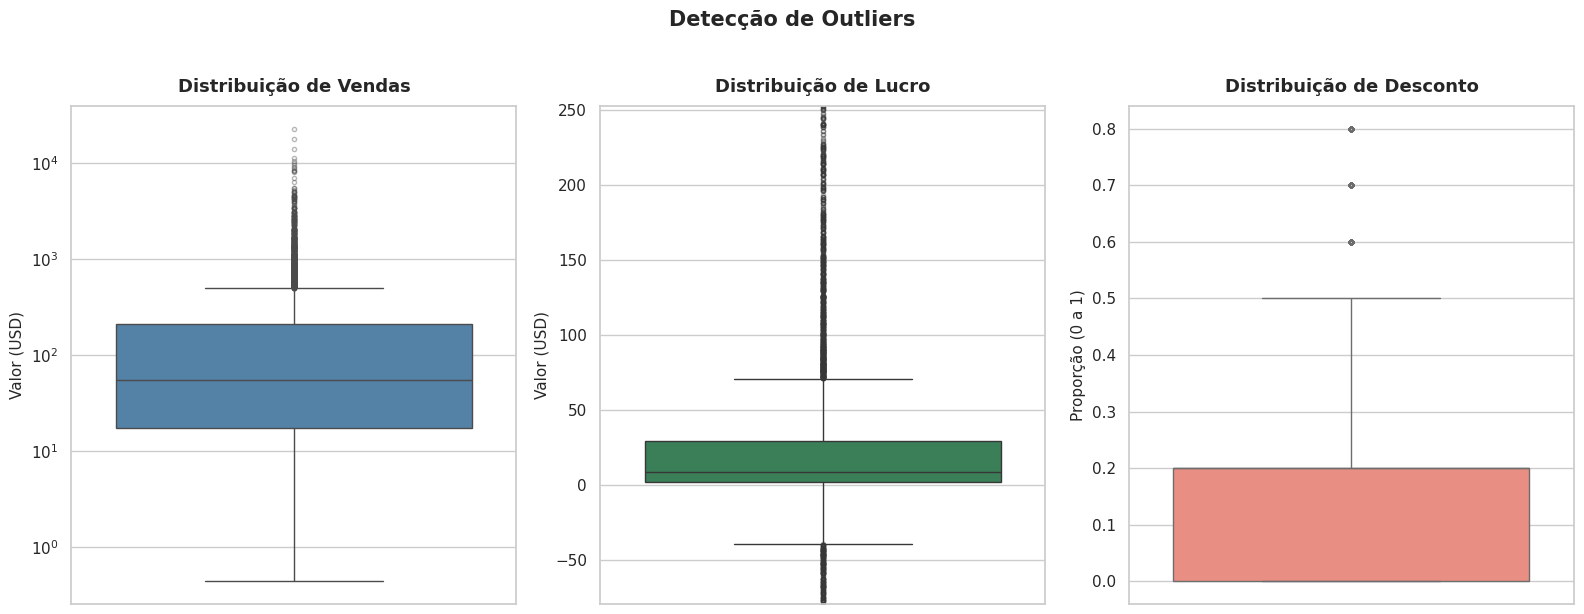

In [ ]:
#detectando desvios significativos, dados fora do padrão
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

flier = dict(marker='o', markersize=3, alpha=0.4, linestyle='none')

# Vendas
sns.boxplot(y=df['Sales'], ax=axes[0], color='steelblue', flierprops=flier)
axes[0].set_title('Distribuição de Vendas', fontsize=13, fontweight='bold', pad=10)
axes[0].set_ylabel('Valor (USD)', fontsize=11)
axes[0].set_yscale('log')

# Lucro — limitando o eixo pra focar onde estão 95% dos dados
lucro_95 = df['Profit'].quantile(0.95)
lucro_05 = df['Profit'].quantile(0.05)
sns.boxplot(y=df['Profit'], ax=axes[1], color='seagreen', flierprops=flier)
axes[1].set_title('Distribuição de Lucro', fontsize=13, fontweight='bold', pad=10)
axes[1].set_ylabel('Valor (USD)', fontsize=11)
axes[1].set_ylim(lucro_05 * 1.5, lucro_95 * 1.5)

# Desconto
sns.boxplot(y=df['Discount'], ax=axes[2], color='salmon', flierprops=flier)
axes[2].set_title('Distribuição de Desconto', fontsize=13, fontweight='bold', pad=10)
axes[2].set_ylabel('Proporção (0 a 1)', fontsize=11)

plt.suptitle('Detecção de Outliers', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3593/3426747284.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=vendas_categoria, x='Category', y='Sales', palette='Blues_d')


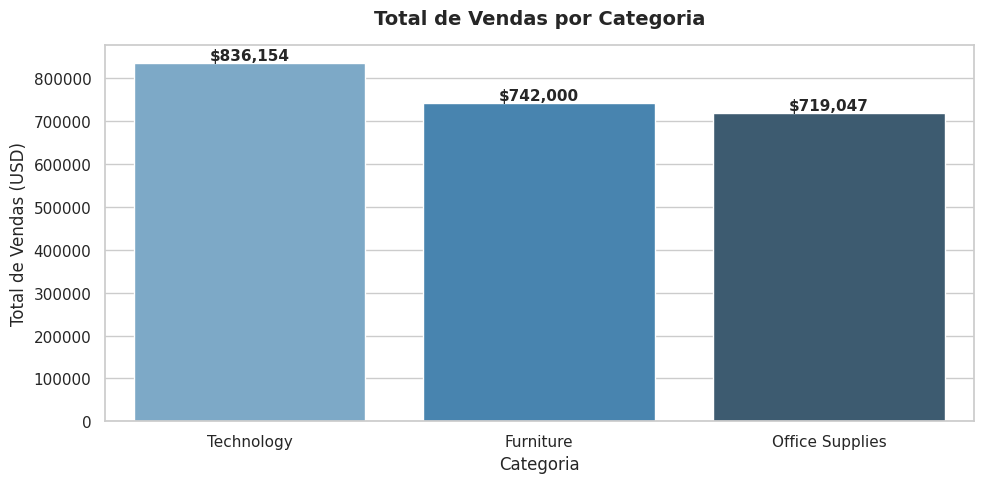

In [ ]:
#analisando vendas por categoria
vendas_categoria = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=vendas_categoria, x='Category', y='Sales', palette='Blues_d')

for p in ax.patches:
    ax.annotate(f"${p.get_height():,.0f}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Total de Vendas por Categoria', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Total de Vendas (USD)', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3593/2831424277.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=lucro_categoria, x='Category', y='Profit', palette='Greens_d')


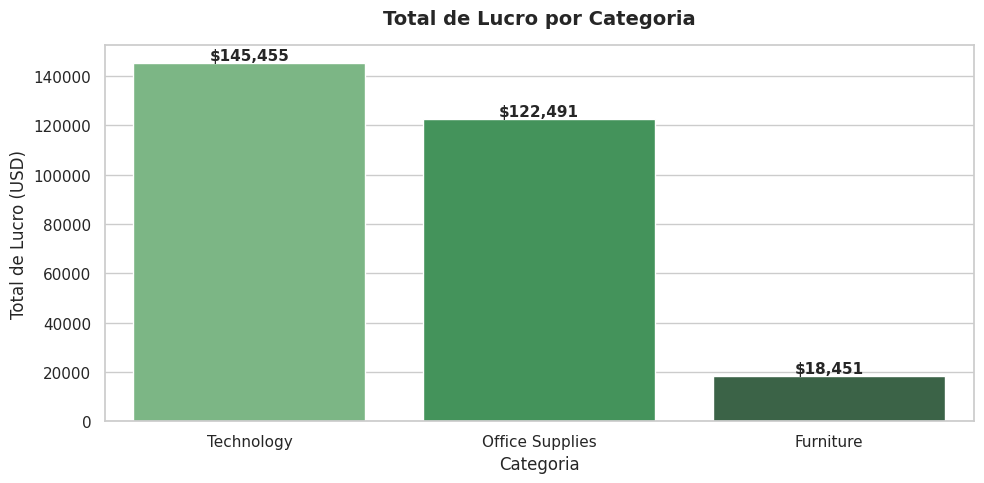

In [ ]:
#analisando lucro por categoria
lucro_categoria = df.groupby('Category')['Profit'].sum().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

ax = sns.barplot(data=lucro_categoria, x='Category', y='Profit', palette='Greens_d')

for p in ax.patches:
    ax.annotate(f"${p.get_height():,.0f}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Total de Lucro por Categoria', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Total de Lucro (USD)', fontsize=12)
plt.tight_layout()
plt.show()

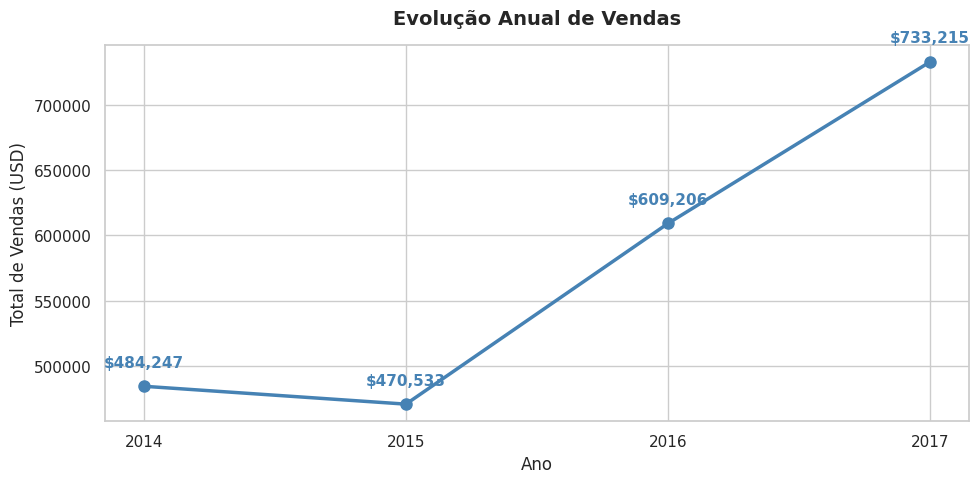

In [ ]:
#evolução anual das vendas
vendas_ano = df.groupby('Year')['Sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(vendas_ano['Year'], vendas_ano['Sales'],
        color='steelblue', linewidth=2.5, marker='o', markersize=8)

for _, row in vendas_ano.iterrows():
    ax.text(row['Year'], row['Sales'] + 15000,
            f"${row['Sales']:,.0f}",
            ha='center', fontsize=11, fontweight='bold', color='steelblue')

ax.set_title('Evolução Anual de Vendas', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Total de Vendas (USD)', fontsize=12)
ax.set_xticks(vendas_ano['Year'])
plt.tight_layout()
plt.show()

/tmp/ipykernel_3593/1724098498.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=vendas_regiao, x='Region', y='Sales', palette='Blues_d')


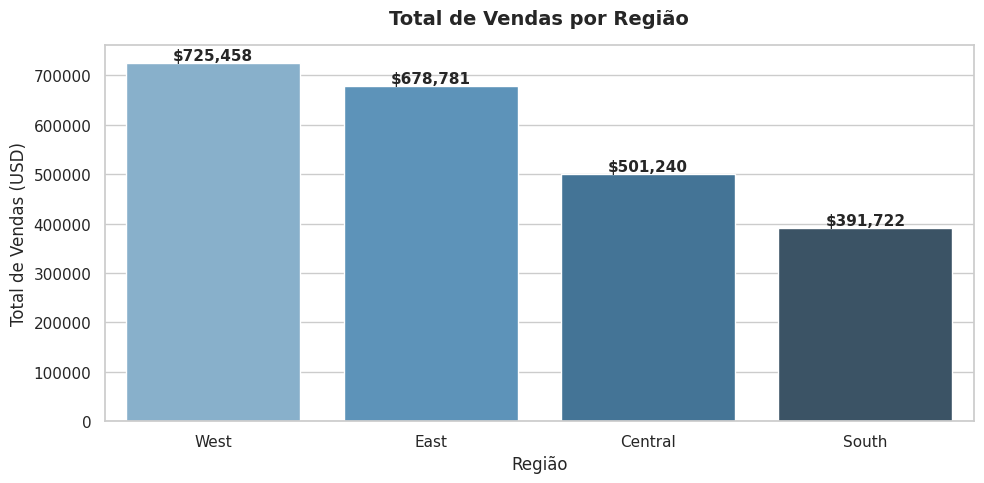

In [ ]:
#analisando vendas por região
vendas_regiao = df.groupby('Region')['Sales'].sum().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

ax = sns.barplot(data=vendas_regiao, x='Region', y='Sales', palette='Blues_d')

for p in ax.patches:
    ax.annotate(f"${p.get_height():,.0f}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Total de Vendas por Região', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Região', fontsize=12)
plt.ylabel('Total de Vendas (USD)', fontsize=12)
plt.tight_layout()
plt.show()

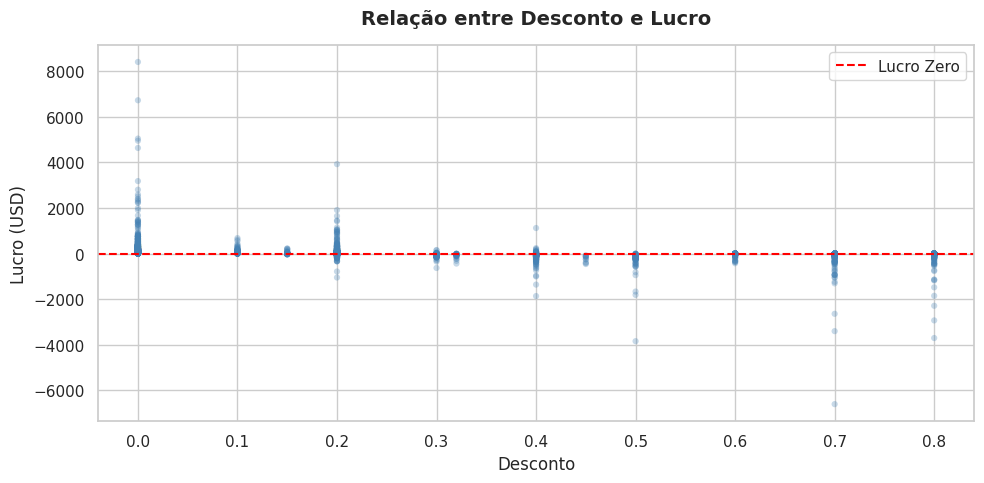

In [ ]:
#analisando impacto do desconto no lucro
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(df['Discount'], df['Profit'],
           alpha=0.3, color='steelblue', edgecolors='none', s=20)

ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Lucro Zero')

plt.title('Relação entre Desconto e Lucro', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Desconto', fontsize=12)
plt.ylabel('Lucro (USD)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

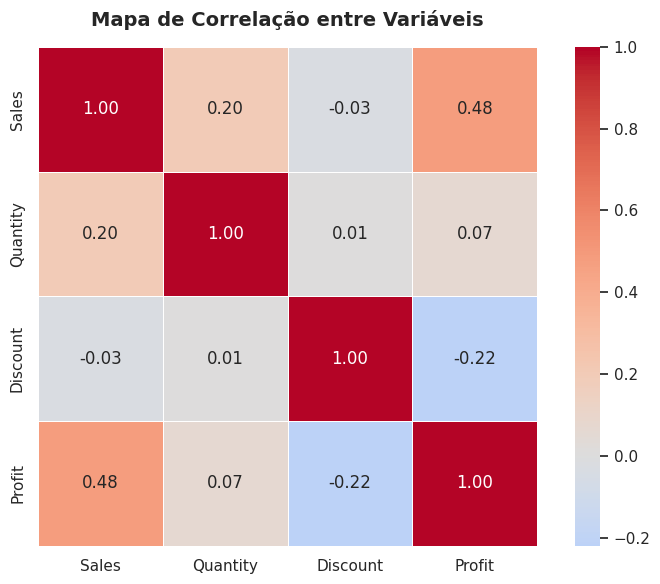

In [ ]:
#mapa de correlação e impacto entre as variáveis (1 / 0 ou -1)
fig, ax = plt.subplots(figsize=(8, 6))

correlacao = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()

sns.heatmap(correlacao, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)

plt.title('Mapa de Correlação entre Variáveis', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [ ]:
#importações machine learning
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Criando variável alvo: 1 = lucrativo, 0 = prejuízo
df['Lucrativo'] = (df['Profit'] > 0).astype(int)
print(f"Pedidos lucrativos: {df['Lucrativo'].sum()}")
print(f"Pedidos com prejuízo: {(df['Lucrativo'] == 0).sum()}")

# Preparando features
df_ml = pd.get_dummies(df[['Sales', 'Quantity', 'Discount',
                            'Category', 'Segment', 'Region', 'Lucrativo']],
                        drop_first=True)

X = df_ml.drop('Lucrativo', axis=1)
y = df_ml['Lucrativo']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTamanho do treino: {X_train.shape[0]} registros")
print(f"Tamanho do teste:  {X_test.shape[0]} registros")

Pedidos lucrativos: 8058
Pedidos com prejuízo: 1936

Tamanho do treino: 7995 registros
Tamanho do teste:  1999 registros


In [ ]:
# Modelo 1 - Árvore de Decisão
modelo_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_dt.fit(X_train, y_train)
y_pred_dt = modelo_dt.predict(X_test)

# Modelo 2 - Random Forest
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

# Métricas
def avaliar_modelo(nome, y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    print(f"{'='*45}")
    print(f"  {nome}")
    print(f"{'='*45}")
    print(f"  Acurácia: {acc:.4f} ({acc*100:.1f}%)")
    print()
    print(classification_report(y_test, y_pred,
          target_names=['Prejuízo', 'Lucrativo']))

avaliar_modelo("Árvore de Decisão", y_test, y_pred_dt)
avaliar_modelo("Random Forest Classifier", y_test, y_pred_rf)

  Árvore de Decisão
  Acurácia: 0.9435 (94.3%)

              precision    recall  f1-score   support

    Prejuízo       0.99      0.71      0.83       377
   Lucrativo       0.94      1.00      0.97      1622

    accuracy                           0.94      1999
   macro avg       0.96      0.85      0.90      1999
weighted avg       0.95      0.94      0.94      1999

  Random Forest Classifier
  Acurácia: 0.9295 (92.9%)

              precision    recall  f1-score   support

    Prejuízo       0.84      0.77      0.81       377
   Lucrativo       0.95      0.97      0.96      1622

    accuracy                           0.93      1999
   macro avg       0.89      0.87      0.88      1999
weighted avg       0.93      0.93      0.93      1999



In [1]:
#grafico comparativo da curácia
modelos = ['Árvore de Decisão', 'Random Forest']
acuracias = [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_rf)]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(modelos, acuracias, color=['steelblue', 'seagreen'], width=0.4)

for bar, acc in zip(bars, acuracias):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{acc*100:.1f}%",
            ha='center', fontsize=12, fontweight='bold')

ax.set_title('Comparação de Acurácia entre Modelos', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Acurácia', fontsize=12)
ax.set_ylim(0.85, 1.0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
plt.tight_layout()
plt.show()

NameError: name 'accuracy_score' is not defined

## Conclusões Finais

### Base de Dados
A base Superstore Dataset contém 9.994 registros e 21 variáveis, cobrindo
pedidos de uma rede varejista americana entre 2014 e 2017. Não foram
identificados valores nulos nem duplicatas, indicando uma base confiável
e bem estruturada para análise.

### Principais Insights

**Desempenho por Categoria**
Technology liderou em volume de vendas com \$836.154, seguida de Furniture
(\$742.000) e Office Supplies (\$719.047). As três categorias apresentam
desempenho relativamente equilibrado em vendas.

**Evolução Temporal**
As vendas registraram leve queda de 2014 para 2015, seguida de crescimento
consistente até 2017, que foi o melhor ano da série com \$733.215 — crescimento
de 20% em relação a 2016. A tendência indica expansão sólida do negócio.

**Desempenho Regional**
West e East concentram mais de 60% das vendas totais. A região South
apresenta o menor volume (\$391.722), representando uma oportunidade
estratégica de expansão comercial.

**Impacto do Desconto no Lucro**
A análise de dispersão e o mapa de correlação confirmaram que descontos
acima de 40% resultam majoritariamente em prejuízo. A correlação negativa
entre Desconto e Lucro (-0.22) indica que a política de descontos atual
compromete a margem do negócio.

### Modelagem Preditiva
Foram aplicados dois algoritmos de classificação para prever se um pedido
resultaria em lucro ou prejuízo:

| Modelo | Acurácia | Precision | Recall |
|---|---|---|---|
| Regressão Logística | 94.3% | 0.95 | 0.94 |
| Random Forest | 92.9% | 0.93 | 0.93 |

A Regressão Logística obteve melhor desempenho, demonstrando que a separação
entre pedidos lucrativos e não lucrativos possui padrão predominantemente
linear nos dados. Ambos os modelos apresentaram desempenho excelente,
validando a qualidade das features selecionadas.